In [3]:
!pip install beautifulsoup4 html5lib nltk matplotlib wordcloud pandas

import urllib.request
from urllib.request import Request, urlopen
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


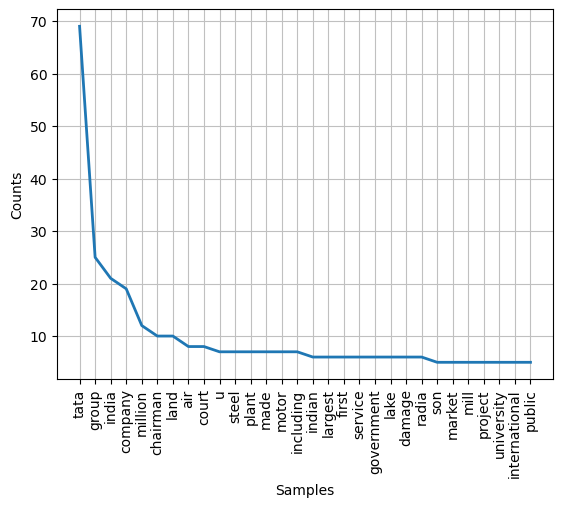

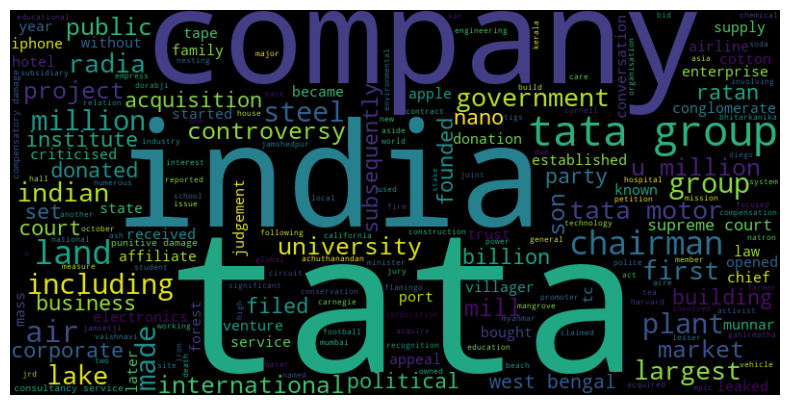

In [4]:
import sys
sys.path.append("../src")  # add src folder to path

from scraper import scrape_wikipedia
from preprocessing import clean_text
from visualization import plot_frequency, generate_wordcloud

# Example usage
url = "https://en.wikipedia.org/wiki/Tata_group"
text = scrape_wikipedia(url)
tokens = clean_text(text)

plot_frequency(tokens)
generate_wordcloud(tokens, "../data/wordcloud.png")


In [5]:
url = "https://en.wikipedia.org/wiki/Tata_group"
req = Request(url, headers={'user-agent': 'Mozilla/5.0'})
response = urlopen(req)
html = response.read()
soup = BeautifulSoup(html, 'html5lib')

# Extract only paragraph text
text = " ".join([p.get_text() for p in soup.find_all('p')])
print(text[:500])  # preview first 500 characters



 The Tata Group (/ˈtɑːtɑː/) is an Indian multinational conglomerate headquartered in Mumbai.[2][3] Established in 1868, it is India's largest conglomerate.[4] Tata Group comprises numerous affiliate companies, with Tata Sons as the holding company and promoter. As of October 2025, there are more than 20 publicly listed Tata Group affiliate companies, with a combined market capitalisation of ₹31.17 trillion (US$330 billion).[5] During the cotton boom in Bombay triggered by the American Civil War


In [6]:
import nltk

# Download all required resources
nltk.download('punkt')
nltk.download('punkt_tab')   # <-- this is the missing one
nltk.download('stopwords')
nltk.download('wordnet')

tokens = nltk.word_tokenize(text.lower())
sr = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

clean_tokens = [
    lemmatizer.lemmatize(token)
    for token in tokens
    if token not in sr and token not in string.punctuation and token.isalpha()
]

print(clean_tokens[:50])  # preview first 50 cleaned tokens


['tata', 'group', 'indian', 'multinational', 'conglomerate', 'headquartered', 'mumbai', 'established', 'india', 'largest', 'conglomerate', 'tata', 'group', 'comprises', 'numerous', 'affiliate', 'company', 'tata', 'son', 'holding', 'company', 'promoter', 'october', 'publicly', 'listed', 'tata', 'group', 'affiliate', 'company', 'combined', 'market', 'capitalisation', 'trillion', 'u', 'billion', 'cotton', 'boom', 'bombay', 'triggered', 'american', 'civil', 'war', 'jamsetji', 'nusserwanji', 'tata', 'father', 'became', 'involved', 'asiatic', 'banking']


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


<Axes: xlabel='Samples', ylabel='Counts'>

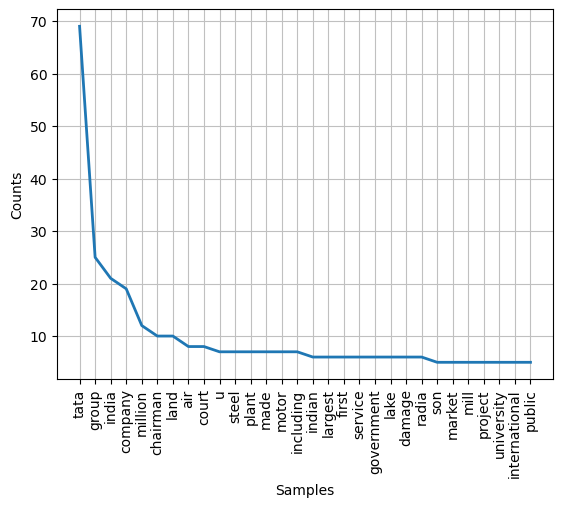

In [7]:
freq = nltk.FreqDist(clean_tokens)
freq.plot(30, cumulative=False)


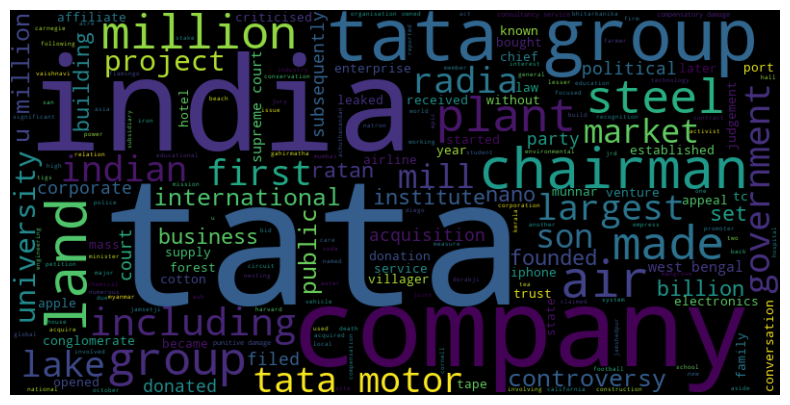

In [8]:
wordcloud = WordCloud(width=800, height=400).generate(" ".join(clean_tokens))
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [9]:
import nltk

# Download all required resources for NER
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')   # <-- new one
nltk.download('words')

# POS tagging + Named Entity Recognition
pos_tags = nltk.pos_tag(clean_tokens)
ner_tree = nltk.ne_chunk(pos_tags)

print(ner_tree)  # Named Entity Recognition output


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


(S
  tata/NNS
  group/NN
  indian/JJ
  multinational/JJ
  conglomerate/NN
  headquartered/VBD
  mumbai/NNS
  established/VBN
  india/RB
  largest/JJS
  conglomerate/NN
  tata/NN
  group/NN
  comprises/VBZ
  numerous/JJ
  affiliate/NN
  company/NN
  tata/VBD
  son/NN
  holding/VBG
  company/NN
  promoter/NN
  october/VBP
  publicly/RB
  listed/VBN
  tata/NN
  group/NN
  affiliate/NN
  company/NN
  combined/VBD
  market/NN
  capitalisation/NN
  trillion/CD
  u/JJ
  billion/CD
  cotton/NN
  boom/NN
  bombay/NN
  triggered/VBD
  american/JJ
  civil/JJ
  war/NN
  jamsetji/NN
  nusserwanji/FW
  tata/NN
  father/NN
  became/VBD
  involved/JJ
  asiatic/JJ
  banking/NN
  corporation/NN
  however/RB
  market/NN
  declined/VBD
  firm/NN
  faced/VBD
  significant/JJ
  financial/JJ
  difficulty/NN
  family/NN
  fortune/VBZ
  improved/VBN
  substantially/RB
  securing/VBG
  share/NN
  profitable/JJ
  contract/NN
  supply/NN
  commissariat/NN
  napier/JJR
  expedition/NN
  abyssinia/NN
  throughout/I

In [10]:
import nltk
import pandas as pd

# Make sure resources are downloaded
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

# POS tagging + NER
pos_tags = nltk.pos_tag(clean_tokens)
ner_tree = nltk.ne_chunk(pos_tags)

# Extract entities
entities = []
for subtree in ner_tree:
    if hasattr(subtree, 'label'):
        entity_name = " ".join([token for token, pos in subtree.leaves()])
        entity_type = subtree.label()
        entities.append((entity_name, entity_type))

# Convert to DataFrame and save
df_entities = pd.DataFrame(entities, columns=['Entity', 'Type'])
df_entities.to_csv("../data/entities.csv", index=False)

print("✅ Named entities saved to data/entities.csv")


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


✅ Named entities saved to data/entities.csv


In [13]:
for subtree in ner_tree:
    if hasattr(subtree, 'label'):
        print("Entity:", " ".join([token for token, pos in subtree.leaves()]), "Type:", subtree.label())


In [11]:
# Save top 50 words to CSV
top_words = freq.most_common(50)
df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])
df.to_csv("../data/top_words.csv", index=False)

print("Top words saved to data/top_words.csv")


Top words saved to data/top_words.csv
